On utilise un notebook pour pouvoir afficher les sorties graphiques

In [6]:
from fonctions import load_gpkg, gdf_DBSCAN
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")



gdf["Annee"].unique()
gdf["aire"] = gdf.geometry.area

centroids = gdf.geometry.centroid
# Conversion en coordonnées géographiques (WGS84)
centroids_wgs84 = gpd.GeoSeries(centroids, crs=2154).to_crs(epsg=4326)
gdf["lon"] = centroids_wgs84.x
gdf["lat"] = centroids_wgs84.y

gdf=gdf[gdf["Annee"].isin([2008,2014,2020,2025])]



Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...


KeyboardInterrupt: 

In [ ]:

#identification de sites industriels et logistiques
temp=gdf_DBSCAN(gdf,2008,eps=200,min_samples=2)
isolés = temp[temp["cluster_id"] == -1].copy()
clusterisés = temp[temp["cluster_id"] != -1].copy()
clusterisés["centroid"] = clusterisés.geometry.centroid
clusters_fusionnes = clusterisés.groupby("cluster_id")["centroid"].apply(
    lambda centroids: Point(
        np.mean([p.x for p in centroids]),
        np.mean([p.y for p in centroids])
    )
).reset_index()
gdf_clusters_fusionnes = gpd.GeoDataFrame(
    clusters_fusionnes, 
    geometry="centroid", 
    crs=temp.crs
)
gdf_clusters_fusionnes = gdf_clusters_fusionnes.set_geometry("centroid")
temp = pd.concat([isolés, gdf_clusters_fusionnes], ignore_index=True)
temp.drop(columns=["cluster_id"], inplace=True)

#clusters 
gdf_DBSCAN(temp,2008,eps=1000,min_samples=3)
gdf_DBSCAN(gdf,2008,eps=1000,min_samples=3)





In [ ]:
len(gdf)

657565

eps : 951, clusters : 0.987, isolés : 0.013


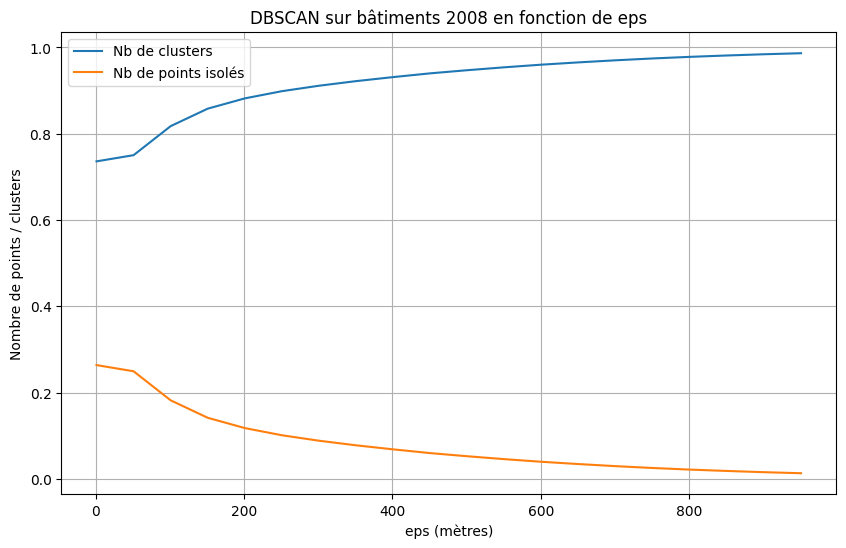

NameError: name 'df' is not defined

In [10]:
from IPython.display import clear_output

#boucle 
eps_values = np.arange(1, 1001, 50)
clusters_list = []
isoles_list = []

for eps in eps_values:
    _, n_clusters, n_isoles = gdf_DBSCAN(gdf,2008, eps=eps, min_samples=5)
    clusters_list.append((len(gdf)-n_isoles)/len(gdf))
    isoles_list.append(n_isoles/len(gdf))
    clear_output(wait=True)   # efface la sortie précédente
    print(f'eps : {eps}, clusters : {clusters_list[-1]:.3f}, isolés : {isoles_list[-1]:.3f}')


# Plot
plt.figure(figsize=(10,6))
plt.plot(eps_values, clusters_list, label="Nb de clusters")
plt.plot(eps_values, isoles_list, label="Nb de points isolés")
plt.xlabel("eps (mètres)")
plt.ylabel("Nombre de points / clusters")
plt.title("DBSCAN sur bâtiments 2008 en fonction de eps")
plt.legend()
plt.grid(True)
plt.show()


print(df.head())